C:\Users\bloom\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bloom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Запрос start=0, max_results=200
Запрос start=200, max_results=200
Запрос start=400, max_results=200
Запрос start=600, max_results=100


2025-09-22 00:51:04 INFO: Downloaded file to C:\Users\bloom\stanza_resources\resources.json
2025-09-22 00:51:04 INFO: Downloading default packages for language: en (English) ...
2025-09-22 00:51:05 INFO: File exists: C:\Users\bloom\stanza_resources\en\default.zip
2025-09-22 00:51:07 INFO: Finished downloading models and saved to C:\Users\bloom\stanza_resources
2025-09-22 00:51:07 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-09-22 00:51:07 INFO: Downloaded file to C:\Users\bloom\stanza_resources\resources.json
2025-09-22 00:51:07 WARNING: Language en package default expects mwt, which has been added
2025-09-22 00:51:07 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| lemma     | combined_nochar

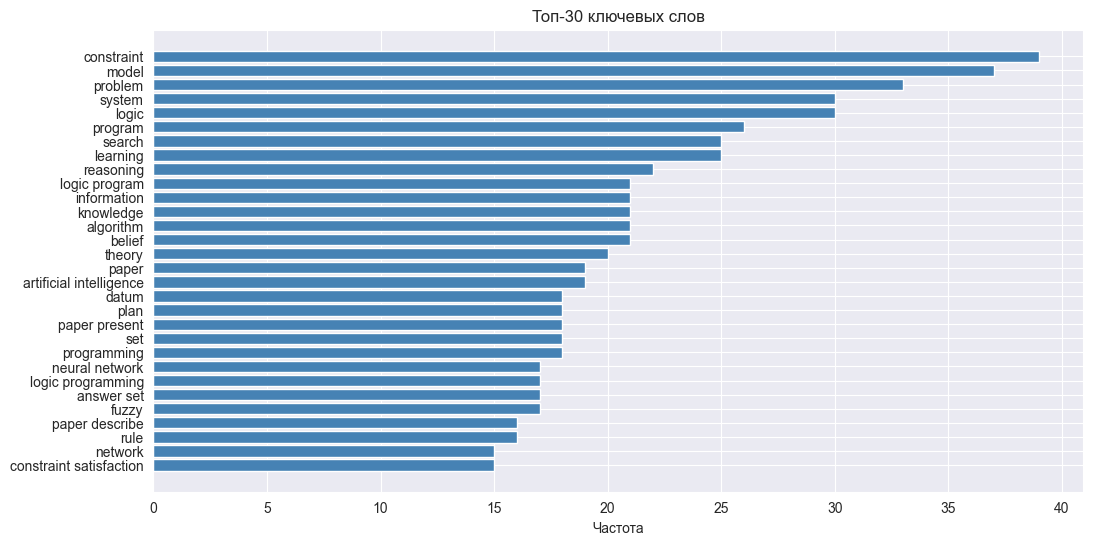

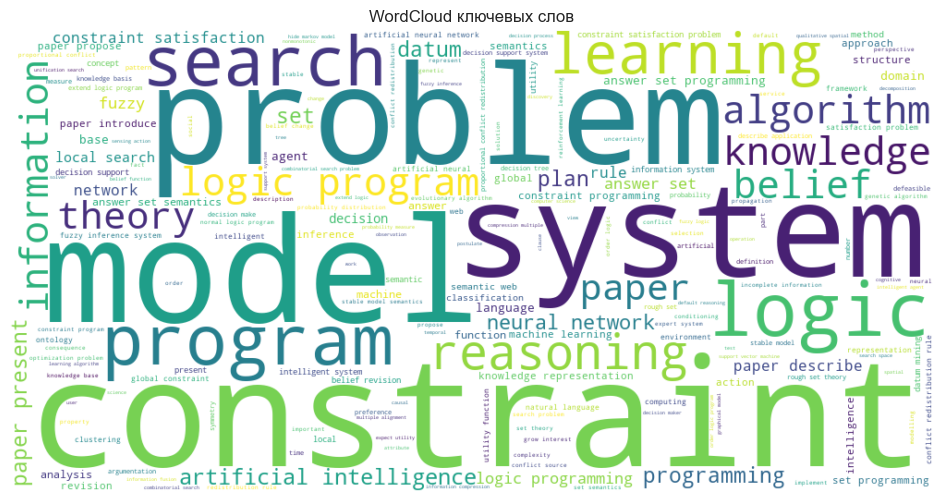

Модулярность кластеризации: 0.8106795790941665

Top-10 по Degree centrality:
model: 0.0595
constraint: 0.0538
problem: 0.0492
system: 0.0480
logic: 0.0423
learning: 0.0401
search: 0.0387
reasoning: 0.0352
information: 0.0348
algorithm: 0.0336

Top-10 по Betweenness centrality:
model: 0.0814
problem: 0.0656
system: 0.0624
learning: 0.0520
paper: 0.0498
paper present: 0.0497
constraint: 0.0491
information: 0.0465
reasoning: 0.0422
search: 0.0407

Top-10 по Eigenvector centrality:
answer set: 0.3294
logic program: 0.3186
program: 0.2924
logic: 0.2748
answer set semantics: 0.2548
answer set programming: 0.2173
set: 0.2124
set programming: 0.2077
answer: 0.2066
programming: 0.1831

Top-10 по Closeness centrality:
model: 0.4006
problem: 0.3946
learning: 0.3943
paper: 0.3871
system: 0.3788
reasoning: 0.3788
constraint: 0.3725
logic: 0.3700
knowledge: 0.3695
paper describe: 0.3669


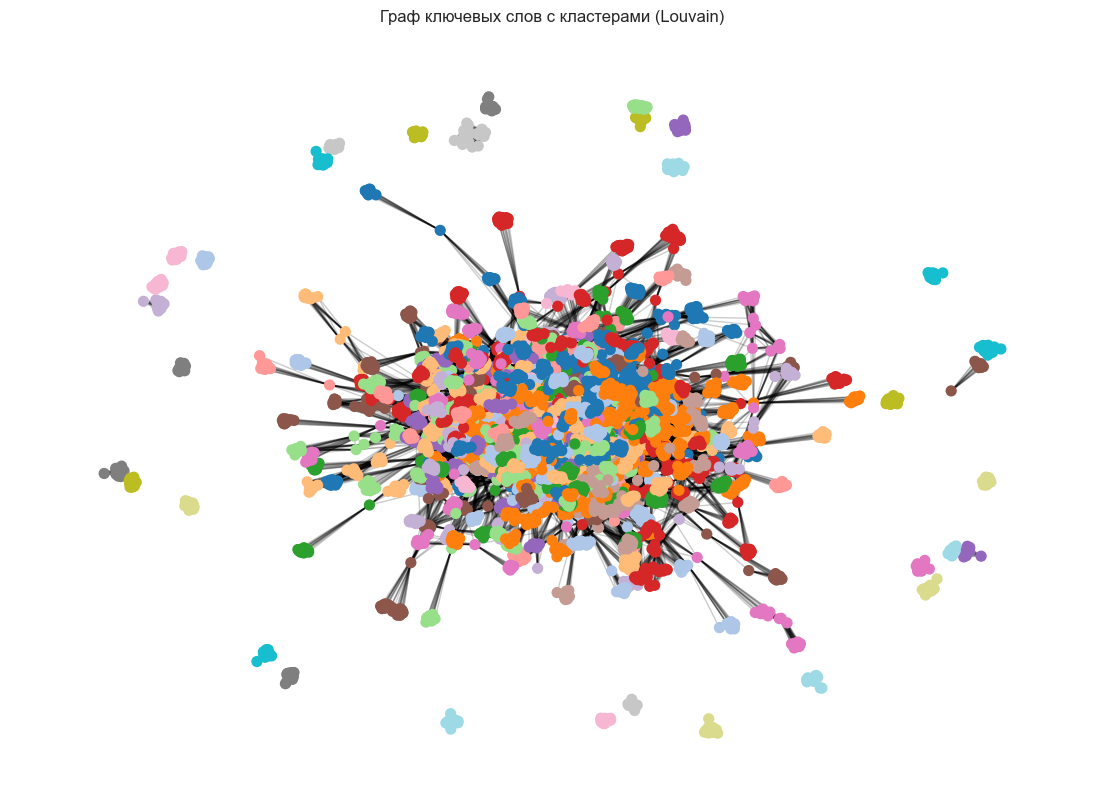


Кластер 0 (примерные ключевые слова): ['progress toward solving', 'exist backtracking method', 'dynamic', 'shallow point', 'meaningful progress']

Кластер 1 (примерные ключевые слова): ['search', 'result', 'unordered search opus', 'enable efficient', 'enable efficient admissible']

Кластер 2 (примерные ключевые слова): ['tree', 'consistent decision tree', 'investigation occam', 'consistent decision', 'empirical investigation']

Кластер 3 (примерные ключевые слова): ['search problem', 'procedural meaning', 'effective learning procedure', 'logic programmers', 'evaluation method']

Кластер 4 (примерные ключевые слова): ['well - understand class', 'market - orient programming', 'price system constitute', 'market - orient programming environment', 'market - orient programming approach']

Кластер 5 (примерные ключевые слова): ['extensive study', 'gsat perform', 'number satisfied', 'procedure propositional', 'gsat perform greedy']

Кластер 6 (примерные ключевые слова): ['learning', 'network'

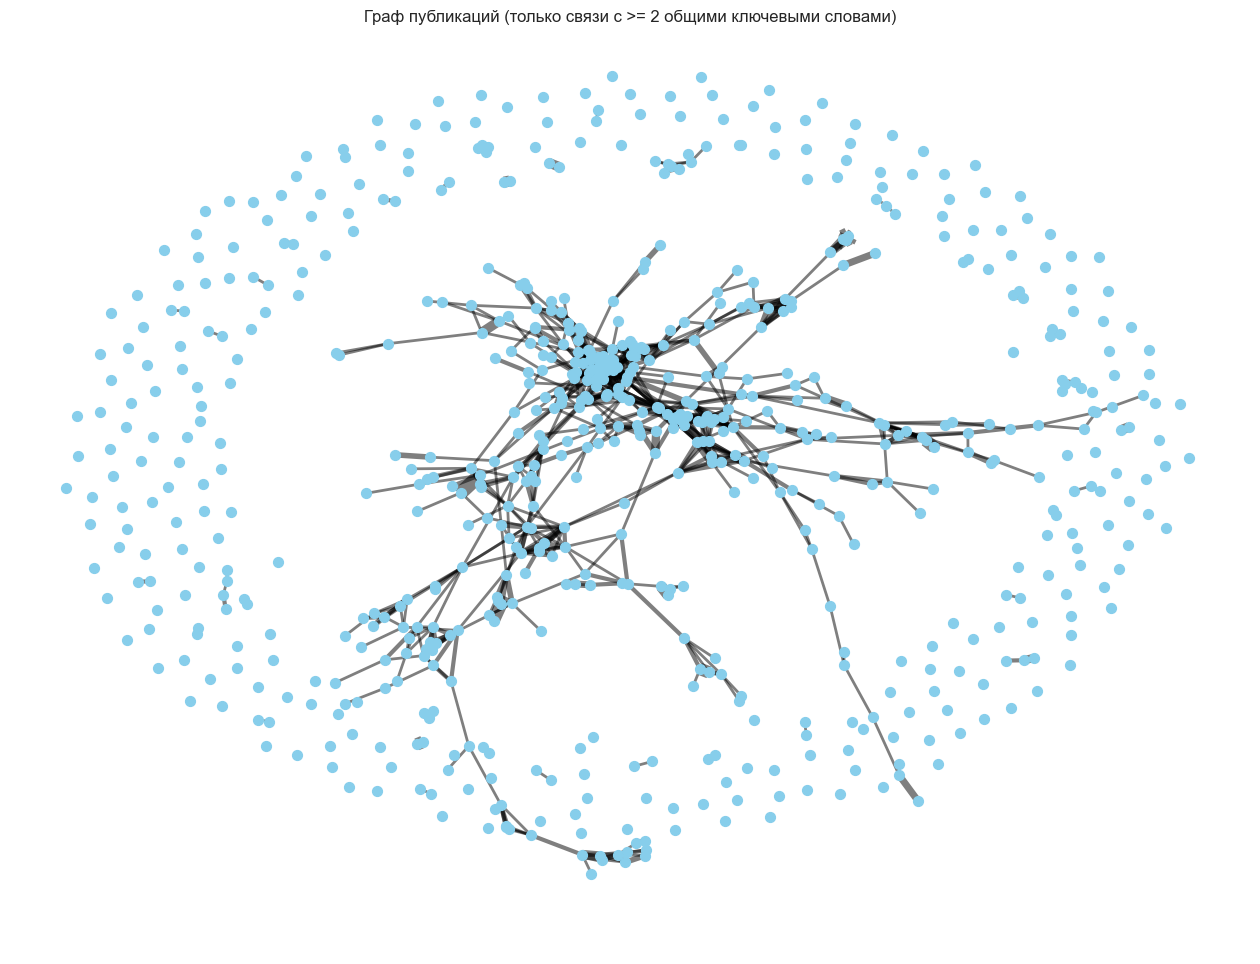


Похожие публикации на: Dynamic Backtracking
Вес связи 2: A New Look at the Easy-Hard-Easy Pattern of Combinatorial Search
  Difficulty

Похожие публикации на: Dynamic Backtracking
Вес связи 2: A New Look at the Easy-Hard-Easy Pattern of Combinatorial Search
  Difficulty
Нет публикаций с общими ключевыми словами выше заданного порога.
Нет публикаций с общими ключевыми словами выше заданного порога.

Похожие публикации на: The Difficulties of Learning Logic Programs with Cut
Вес связи 2: On Planning while Learning
Вес связи 2: Pac-Learning Recursive Logic Programs: Efficient Algorithms
Вес связи 2: Well-Founded Semantics for Extended Logic Programs with Dynamic
  Preferences
Вес связи 2: Practical Methods for Proving Termination of General Logic Programs
Вес связи 2: Consistency Management of Normal Logic Program by Top-down Abductive
  Proof Procedure
Нет публикаций с общими ключевыми словами выше заданного порога.

Похожие публикации на: Decidable Reasoning in Terminological Knowledge

In [1]:
# === Импорты ===
import requests, time, xml.etree.ElementTree as ET
import pandas as pd
import yake, stanza, nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import networkx as nx
import itertools
from nltk.corpus import stopwords
from community import community_louvain

# Настройка отображения
plt.rcParams['figure.figsize'] = (12,6)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Пространства имён arXiv API
NS = {
    'atom': 'http://www.w3.org/2005/Atom',
    'opensearch': 'http://a9.com/-/spec/opensearch/1.1/',
    'arxiv': 'http://arxiv.org/schemas/atom'
}

# === 1. Скачивание данных ===
def parse_entry(entry_elem):
    def get_text(path):
        el = entry_elem.find(path, NS)
        return el.text.strip() if el is not None and el.text else ""
    return {
        "id": get_text('atom:id'),
        "title": get_text('atom:title'),
        "summary": get_text('atom:summary'),
        "authors": [a.find('atom:name', NS).text.strip()
                    for a in entry_elem.findall('atom:author', NS)
                    if a.find('atom:name', NS) is not None],
        "categories": [c.attrib.get('term')
                       for c in entry_elem.findall('atom:category', NS)]
    }

def fetch_arxiv(search_query="cat:cs.AI", total=700, per_call=200, sleep_s=3.0):
    API_ENDPOINT = "http://export.arxiv.org/api/query"
    results, start = [], 0
    while len(results) < total:
        to_request = min(per_call, total - len(results))
        params = {"search_query": search_query, "start": start, "max_results": to_request}
        print(f"Запрос start={start}, max_results={to_request}")
        resp = requests.get(API_ENDPOINT, params=params, timeout=60)
        resp.raise_for_status()
        root = ET.fromstring(resp.text)
        entries = root.findall('atom:entry', NS)
        if not entries:
            break
        for e in entries:
            results.append(parse_entry(e))
            if len(results) >= total:
                break
        start += to_request
        if len(results) < total:
            time.sleep(sleep_s)
    return results

# Загружаем публикации
data = fetch_arxiv("cat:cs.AI", total=700, per_call=200)
df = pd.DataFrame(data)

# === 2. Извлечение ключевых слов ===
yake_extractor = yake.KeywordExtractor(lan="en", n=3, dedupLim=0.85, top=15)

def extract_keywords(text):
    text = text.lower()
    keywords = yake_extractor.extract_keywords(text)
    return [kw[0] for kw in keywords]

df["keywords"] = (df["title"] + " " + df["summary"]).apply(extract_keywords)

# Лемматизация через stanza
stanza.download('en')
nlp = stanza.Pipeline('en', processors='tokenize,lemma', use_gpu=False)

def lemmatize_keywords(keywords):
    lemmas = []
    for phrase in keywords:
        doc = nlp(phrase)
        lemmatized_words = [word.lemma for word in doc.iter_words()]
        lemmas.append(" ".join(lemmatized_words))
    return lemmas

df["lemmatized_keywords"] = df["keywords"].apply(lemmatize_keywords)

# Очистка от стоп-слов
def clean_keywords(keywords):
    cleaned = []
    for phrase in keywords:
        words = phrase.split()
        filtered = [w for w in words if w not in stop_words]
        if filtered:
            cleaned.append(" ".join(filtered))
    return cleaned

df["cleaned_keywords"] = df["lemmatized_keywords"].apply(clean_keywords)

# === 3. Частотный анализ ключевых слов ===
all_keywords = [kw for kws in df["cleaned_keywords"] for kw in kws]
keyword_freq = Counter(all_keywords)

# Top-30
most_common = keyword_freq.most_common(30)
top_words = [w for w,_ in most_common]
top_counts = [c for _,c in most_common]

plt.figure(figsize=(12,6))
plt.barh(top_words[::-1], top_counts[::-1], color='steelblue')
plt.xlabel("Частота")
plt.title("Топ-30 ключевых слов")
plt.show()

# WordCloud
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate_from_frequencies(keyword_freq)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud ключевых слов")
plt.show()

# === 4. Граф ключевых слов ===
G = nx.Graph()
for keywords in df["cleaned_keywords"]:
    for w1, w2 in itertools.combinations(set(keywords), 2):
        if G.has_edge(w1, w2):
            G[w1][w2]["weight"] += 1
        else:
            G.add_edge(w1, w2, weight=1)

# Кластеризация Louvain + модулярность
partition = community_louvain.best_partition(G, weight="weight")
nx.set_node_attributes(G, partition, "community")
modularity = community_louvain.modularity(partition, G, weight='weight')
print("Модулярность кластеризации:", modularity)

# Центральности
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="weight")
eigenvector_centrality = nx.eigenvector_centrality(G, weight="weight")
closeness_centrality = nx.closeness_centrality(G)

centralities = {
    "Degree": degree_centrality,
    "Betweenness": betweenness_centrality,
    "Eigenvector": eigenvector_centrality,
    "Closeness": closeness_centrality
}

for name, cent in centralities.items():
    top10 = sorted(cent.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\nTop-10 по {name} centrality:")
    for word, score in top10:
        print(f"{word}: {score:.4f}")

# Визуализация графа ключевых слов
colors = [partition[n] for n in G.nodes()]
plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, k=0.15, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Граф ключевых слов с кластерами (Louvain)")
plt.axis('off')
plt.show()

# Интерпретация кластеров
cluster_words = {}
for node, cluster_id in partition.items():
    cluster_words.setdefault(cluster_id, []).append(node)
for cid, words in cluster_words.items():
    print(f"\nКластер {cid} (примерные ключевые слова): {words[:5]}")

# === 5. Граф публикаций ===
H = nx.Graph()
for i, row in df.iterrows():
    H.add_node(i, title=row["title"])

for i, j in itertools.combinations(df.index, 2):
    common = set(df.loc[i, "cleaned_keywords"]) & set(df.loc[j, "cleaned_keywords"])
    if common:
        H.add_edge(i, j, weight=len(common))

# Фильтрация сильных связей
min_weight = 2
strong_edges = [(u, v, d) for u, v, d in H.edges(data=True) if d['weight'] >= min_weight]
H_strong = nx.Graph()
H_strong.add_nodes_from(H.nodes(data=True))
H_strong.add_edges_from(strong_edges)
print(f"Граф публикаций после фильтрации (ребра >= {min_weight}): узлов={H_strong.number_of_nodes()}, рёбер={H_strong.number_of_edges()}")

# Визуализация графа публикаций
plt.figure(figsize=(16,12))
pos = nx.spring_layout(H_strong, k=0.15, seed=42)
nx.draw_networkx_nodes(H_strong, pos, node_size=50, node_color='skyblue')
edge_widths = [d['weight'] for (_, _, d) in H_strong.edges(data=True)]
nx.draw_networkx_edges(H_strong, pos, width=edge_widths, alpha=0.5)
plt.title(f"Граф публикаций (только связи с >= {min_weight} общими ключевыми словами)")
plt.axis('off')
plt.show()

# Функция поиска похожих публикаций на сильных связях
def find_similar_papers_strong(idx, top_n=5):
    if idx not in H_strong:
        print(f"Публикация с индексом {idx} не найдена в графе после фильтрации.")
        return []
    neighbors = H_strong[idx]
    if not neighbors:
        print("Нет публикаций с общими ключевыми словами выше заданного порога.")
        return []
    scores = [(n, H_strong[idx][n]['weight']) for n in neighbors]
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]
    result = [(df.loc[n, "title"], w) for n, w in scores]
    print(f"\nПохожие публикации на: {df.loc[idx, 'title']}")
    for title, weight in result:
        print(f"Вес связи {weight}: {title}")
    return result

# Пример использования
find_similar_papers_strong(0, top_n=5)

# Прогон для всех статей и сохранение в файл рядом со скриптом
similarities = {}

for idx in df.index:
    result = find_similar_papers_strong(idx, top_n=5)
    similarities[idx] = result

# Собираем всё в DataFrame
all_similar = []
for idx, sims in similarities.items():
    for title, weight in sims:
        all_similar.append({
            "source_idx": idx,
            "source_title": df.loc[idx, "title"],
            "similar_title": title,
            "weight": weight
        })

all_similar_df = pd.DataFrame(all_similar)

# Сохраняем в текущую директорию
all_similar_df.to_csv("similar_papers.csv", index=False, encoding="utf-8")

print("Файл 'similar_papers.csv' сохранён в текущей директории.")
